In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/Users/kylejonespatricia/Documents/Combined_sentiment 1840-1963.csv")

df.drop("Unnamed: 0", axis=1, inplace=True)
df["year"] = pd.to_datetime(df["year"], format="%Y")
df = df.sort_values("year")
df.set_index("year", inplace=True)

In [4]:
df.head()

,composite,negative,positive,Topic
year,,,,
1850-01-01,0.99993,0.03975,0.10175,Economy
1850-01-01,0.99982,0.05355,0.10665,Freedom
1850-01-01,0.99986,0.05675,0.10055,Democracy
1850-01-01,0.80615,0.04625,0.08960,Liberty
1851-01-01,0.99991,0.04860,0.10575,Economy


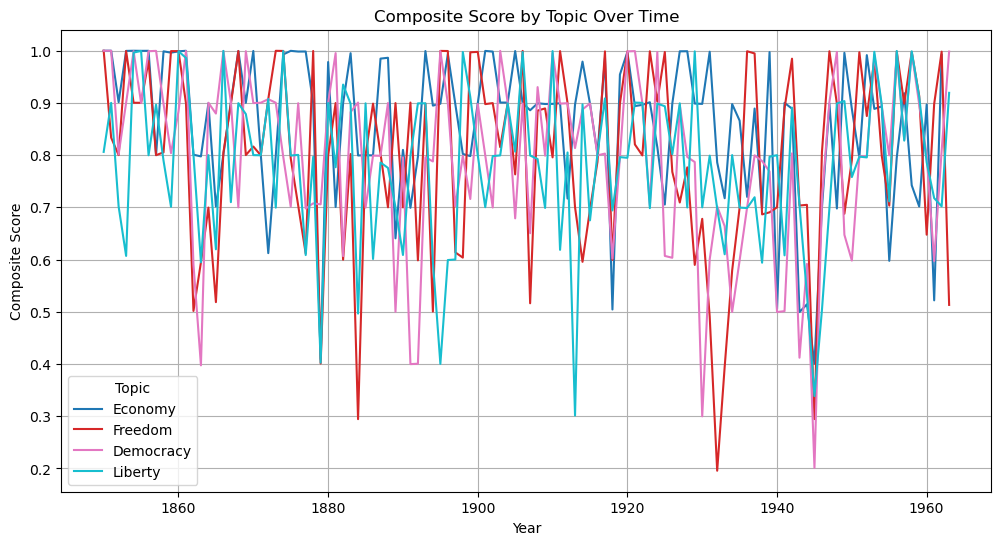

In [22]:
topics = df["Topic"].unique()
colors = plt.get_cmap("tab10", len(topics))

# Plot the data
plt.figure(figsize=(12, 6))
for i, topic in enumerate(topics):
    subset = df[df["Topic"] == topic]
    plt.plot(
        subset.index, subset["composite"], linestyle="-", label=topic, color=colors(i)
    )

plt.xlabel("Year")
plt.ylabel("Composite Score")
plt.title("Composite Score by Topic Over Time")
plt.legend(title="Topic")
plt.grid(True)

# Save the figure
plt.savefig("composite_score_by_topic.png")

# Show the plot
plt.show()

/var/folders/c8/g7bx7g1552g19xn4q4dd583r0000gn/T/ipykernel_9358/3828903162.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(topics))


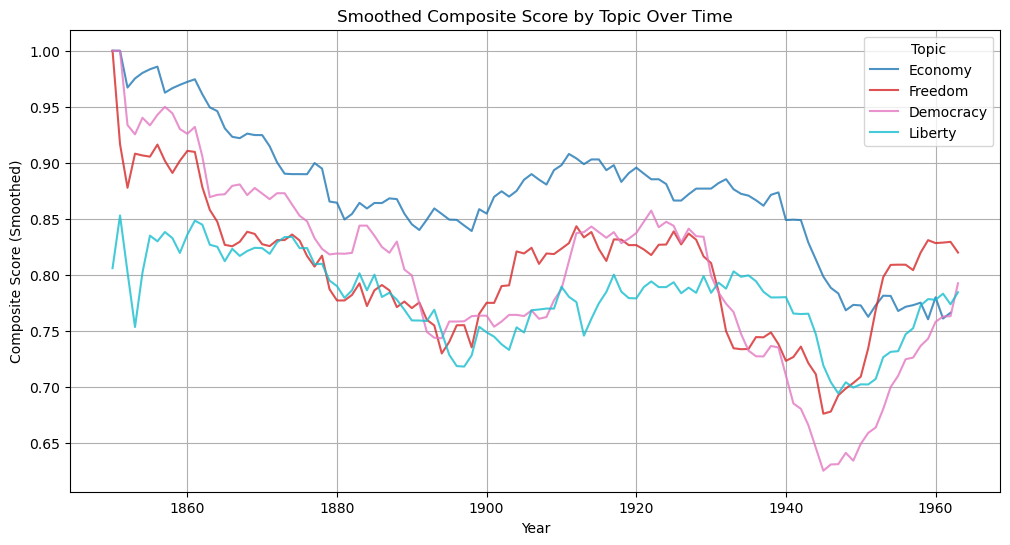

In [28]:
# Apply a rolling mean to smooth the lines (adjust window size as needed)
df["composite_smooth"] = df.groupby("Topic")["composite"].transform(
    lambda x: x.rolling(window=20, min_periods=1).mean()
)

# Generate unique colors for each topic
topics = df["Topic"].unique()
colors = plt.cm.get_cmap("tab10", len(topics))

# Plot the smoothed data
plt.figure(figsize=(12, 6))
for i, topic in enumerate(topics):
    subset = df[df["Topic"] == topic]
    plt.plot(
        subset.index,
        subset["composite_smooth"],
        linestyle="-",
        label=topic,
        color=colors(i),
        alpha=0.8,
    )

plt.xlabel("Year")
plt.ylabel("Composite Score (Smoothed)")
plt.title("Smoothed Composite Score by Topic Over Time")
plt.legend(title="Topic")
plt.grid(True)

# Save the figure
plt.savefig("smoothed_composite_score_by_topic.png")

# Show the plot
plt.show()

/var/folders/c8/g7bx7g1552g19xn4q4dd583r0000gn/T/ipykernel_9358/1275614885.py:29: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = plt.cm.get_cmap("tab10", len(topics))


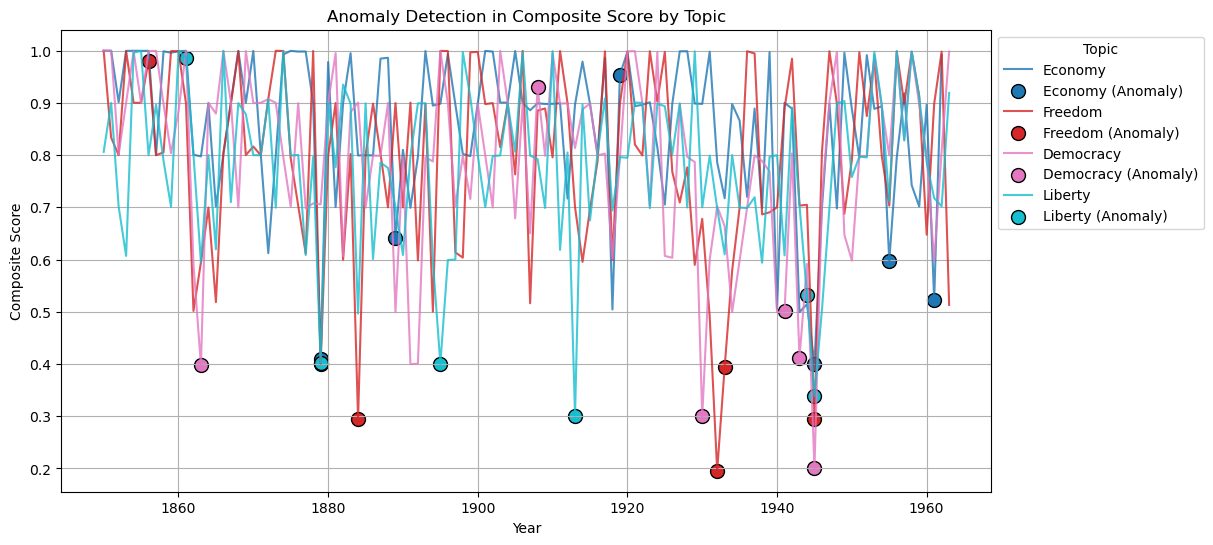

In [32]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.ensemble import IsolationForest


# Prepare for anomaly detection
df["anomaly"] = False  # Placeholder

# Initialize Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)

# Apply anomaly detection per topic
anomaly_dfs = []
for topic in df["Topic"].unique():
    subset = df[df["Topic"] == topic].copy()

    # Fit Isolation Forest
    subset["anomaly"] = iso_forest.fit_predict(subset[["composite"]]) == -1

    # Store results
    anomaly_dfs.append(subset)

# Merge results
df_anomalies = pd.concat(anomaly_dfs)

# Generate unique colors for each topic
topics = df["Topic"].unique()
colors = plt.cm.get_cmap("tab10", len(topics))

# Plot the data with anomalies
plt.figure(figsize=(12, 6))
for i, topic in enumerate(topics):
    subset = df_anomalies[df_anomalies["Topic"] == topic]

    # Normal points
    plt.plot(
        subset.index,
        subset["composite"],
        linestyle="-",
        label=topic,
        color=colors(i),
        alpha=0.8,
    )

    # Anomalies
    anomalies = subset[subset["anomaly"]]
    plt.scatter(
        anomalies.index,
        anomalies["composite"],
        color=colors(i),
        marker="o",
        edgecolor="black",
        s=100,
        label=f"{topic} (Anomaly)",
    )

plt.xlabel("Year")
plt.ylabel("Composite Score")
plt.title("Anomaly Detection in Composite Score by Topic")
plt.legend(title="Topic", loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)

# Save the figure
plt.savefig("anomaly_composite_score_by_topic.png")

# Show the plot
plt.show()

In [34]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# Pivot the data to get topics as columns
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Compute rolling correlation (window size can be adjusted)
rolling_corr = df_pivot.rolling(window=10, min_periods=5).corr()

# Store years for animation
years = rolling_corr.index.get_level_values(0).unique()

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.animation as animation


# Pivot the data to get topics as columns
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Compute rolling correlation (window size can be adjusted)
rolling_corr = df_pivot.rolling(window=10, min_periods=5).corr()

# Store years for animation
years = rolling_corr.index.get_level_values(0).unique()

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))


def update(year):
    ax.clear()
    corr_matrix = rolling_corr.loc[year]
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, ax=ax)
    ax.set_title(f"Rolling Correlation Matrix - Year: {year.year}")


# Create animation
ani = animation.FuncAnimation(fig, update, frames=years, repeat=False)

# Save animation as GIF
ani.save("rolling_correlation.gif", writer="pillow", fps=5)

print("GIF saved as 'rolling_correlation.gif'")

/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/lib/python3.

GIF saved as 'rolling_correlation.gif'


/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:202: RuntimeWarning: All-NaN slice encountered
  vmin = np.nanmin(calc_data)
/opt/anaconda3/lib/python3.12/site-packages/seaborn/matrix.py:207: RuntimeWarning: All-NaN slice encountered
  vmax = np.nanmax(calc_data)


In [38]:
%matplotlib inline

In [48]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.animation as animation


# Pivot the data to get topics as columns
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Compute rolling correlation (window size can be adjusted)
rolling_corr = df_pivot.rolling(window=10, min_periods=5).corr()

# Store years for animation
years = rolling_corr.index.get_level_values(0).unique()

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))

# Get a sample correlation matrix for setting a fixed structure
initial_corr_matrix = rolling_corr.loc[years[0]]


# Function to update frames
def update(year):
    ax.clear()
    corr_matrix = rolling_corr.loc[year]

    # Plot heatmap without the color bar
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        cbar=False,
        vmin=-1,
        vmax=1,  # Keep scale consistent across frames
    )

    ax.set_title(f"Rolling Correlation Matrix - Year: {year.year}")


# Create animation
ani = animation.FuncAnimation(fig, update, frames=years, repeat=False)

# Save animation as GIF
ani.save("rolling_correlation.gif", writer="pillow", fps=5)

print("GIF saved as 'rolling_correlation.gif'")

GIF saved as 'rolling_correlation.gif'


In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.animation as animation


# Pivot the data to get topics as columns
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Compute rolling correlation (window size can be adjusted)
rolling_corr = df_pivot.rolling(window=10, min_periods=5).corr()

# Store years for animation
years = rolling_corr.index.get_level_values(0).unique()

# Get a sample correlation matrix to define the structure
initial_corr_matrix = rolling_corr.loc[years[0]]

# Create a mask to hide the upper triangle
mask = np.triu(np.ones_like(initial_corr_matrix, dtype=bool))

# Create figure
fig, ax = plt.subplots(figsize=(10, 8))


# Function to update frames
def update(year):
    ax.clear()
    corr_matrix = rolling_corr.loc[year]

    # Plot lower triangle only (masked upper triangle)
    sns.heatmap(
        corr_matrix,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0,
        ax=ax,
        cbar=False,
        vmin=-1,
        vmax=1,
        mask=mask,  # Apply the mask
    )

    ax.set_title(f"Rolling Correlation Matrix - Year: {year.year}")


# Create animation
ani = animation.FuncAnimation(fig, update, frames=years, repeat=False)

# Save animation as GIF
ani.save("rolling_correlation.gif", writer="pillow", fps=5)

print("GIF saved as 'rolling_correlation.gif'")

GIF saved as 'rolling_correlation.gif'


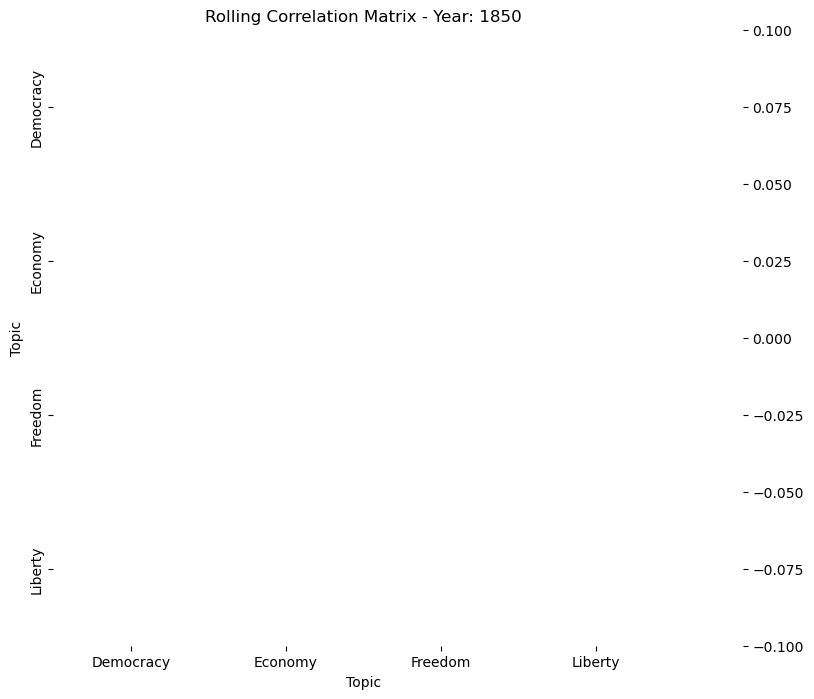

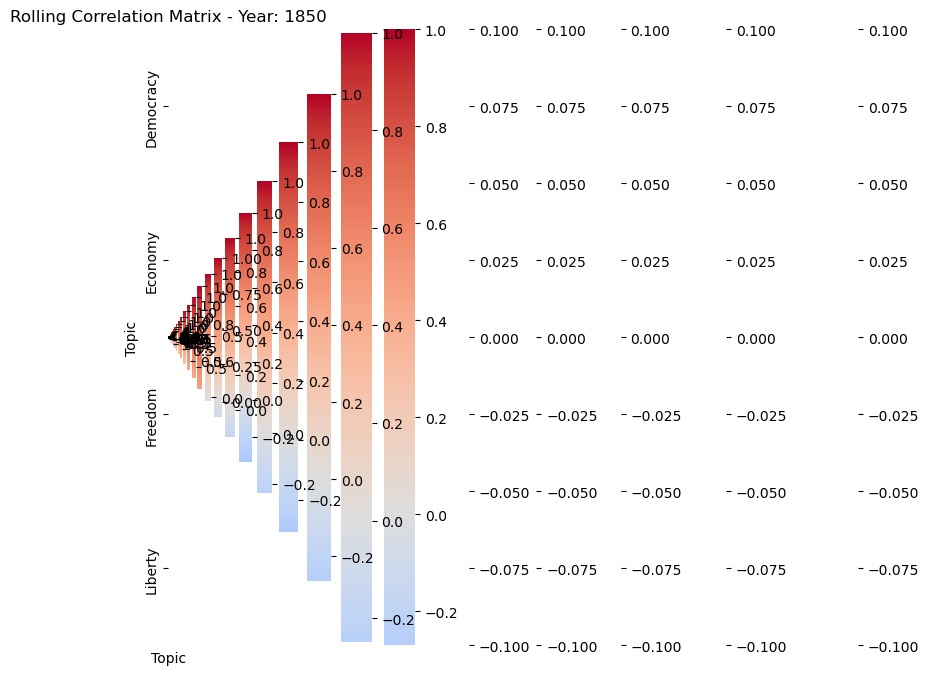

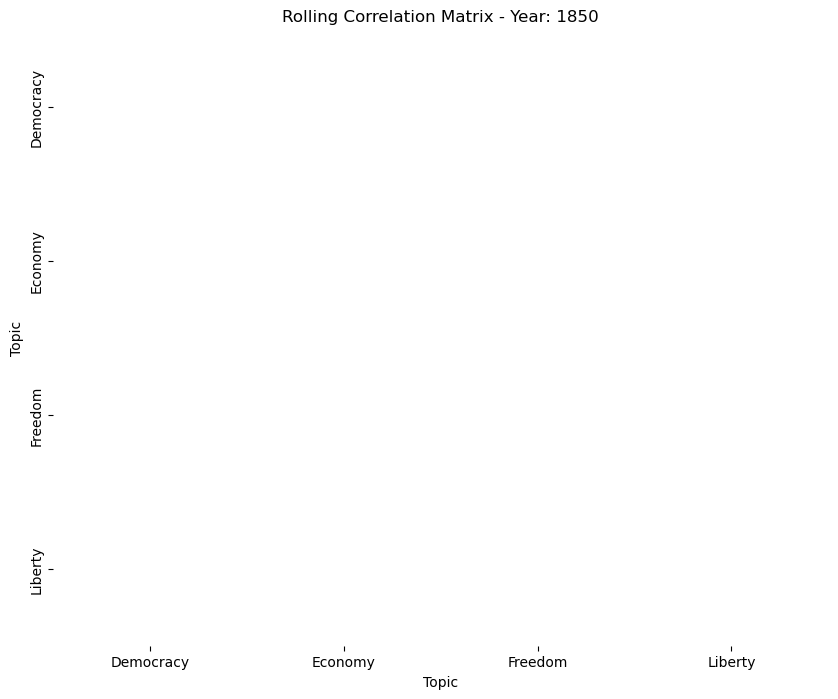

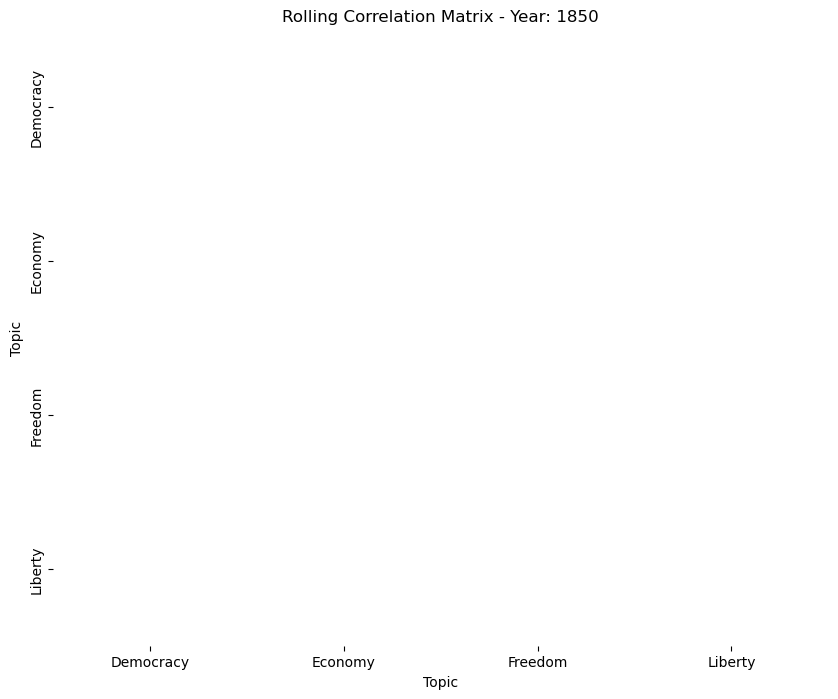

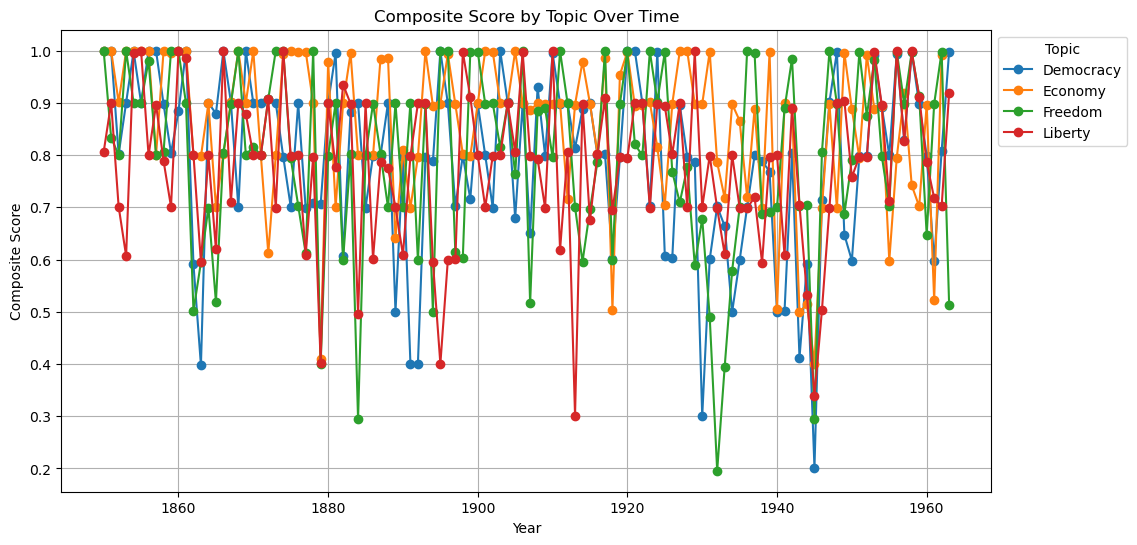

In [52]:
import pandas as pd
import matplotlib.pyplot as plt


# Pivot the data so each topic is a separate column
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Plot the time series data
plt.figure(figsize=(12, 6))
for column in df_pivot.columns:
    plt.plot(df_pivot.index, df_pivot[column], marker="o", linestyle="-", label=column)

plt.xlabel("Year")
plt.ylabel("Composite Score")
plt.title("Composite Score by Topic Over Time")
plt.legend(title="Topic", loc="upper left", bbox_to_anchor=(1, 1))
plt.grid(True)

# Save the figure
plt.savefig("composite_score_time_series.png")

# Show the plot
plt.show()

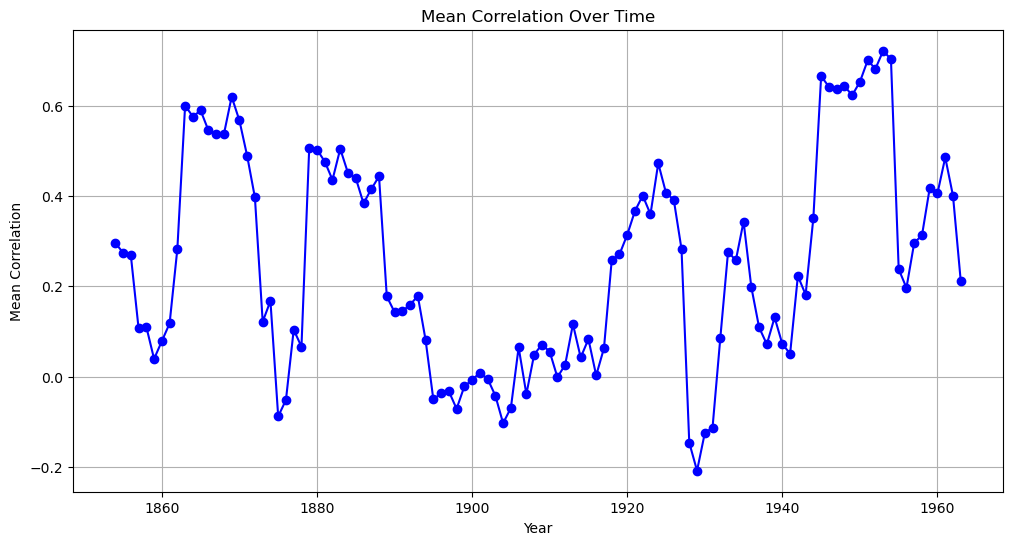

In [54]:
import matplotlib.pyplot as plt
import pandas as pd


# Pivot the data so each topic is a separate column
df_pivot = df.pivot_table(index="year", columns="Topic", values="composite")

# Compute rolling correlation (window size can be adjusted)
rolling_corr = df_pivot.rolling(window=10, min_periods=5).corr(pairwise=True)

# Extract lower triangle correlations (avoid duplicate pairs)
correlation_over_time = {}
years = rolling_corr.index.get_level_values(0).unique()
for year in years:
    corr_matrix = rolling_corr.loc[year]
    lower_triangle = corr_matrix.where(~np.triu(np.ones(corr_matrix.shape, dtype=bool)))
    mean_corr = lower_triangle.mean().mean()  # Get overall correlation trend
    correlation_over_time[year] = mean_corr

# Convert to DataFrame for plotting
corr_df = pd.DataFrame(
    list(correlation_over_time.items()), columns=["Year", "Mean_Correlation"]
).set_index("Year")

# Plot the correlations over time
plt.figure(figsize=(12, 6))
plt.plot(
    corr_df.index, corr_df["Mean_Correlation"], marker="o", linestyle="-", color="b"
)

plt.xlabel("Year")
plt.ylabel("Mean Correlation")
plt.title("Mean Correlation Over Time")
plt.grid(True)

# Save the figure
plt.savefig("correlation_over_time.png")

# Show the plot
plt.show()

In [58]:
corr_df.head(10)

,Mean_Correlation
Year,
1850-01-01,NaN
1851-01-01,NaN
1852-01-01,NaN
1853-01-01,NaN
1854-01-01,0.295882
1855-01-01,0.274748
1856-01-01,0.269296
1857-01-01,0.107107
1858-01-01,0.110424


In [60]:
import statsmodels.api as sm

# Drop NaN values from the correlation dataset
df_corr = corr_df.dropna().copy()

# Prepare the independent (X) and dependent (Y) variables
X = sm.add_constant(df_corr.index.year)  # Add constant for intercept
Y = df_corr["Mean_Correlation"]

# Fit an Ordinary Least Squares (OLS) regression model
model = sm.OLS(Y, X).fit()

# Get summary of the regression
regression_summary = model.summary()

# Display regression results
print(regression_summary)

                            OLS Regression Results                            
Dep. Variable:       Mean_Correlation   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.324
Date:                Sun, 09 Feb 2025   Prob (F-statistic):              0.252
Time:                        12:47:59   Log-Likelihood:                 3.1189
No. Observations:                 110   AIC:                            -2.238
Df Residuals:                     108   BIC:                             3.163
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.3125      1.361     -0.965      0.3

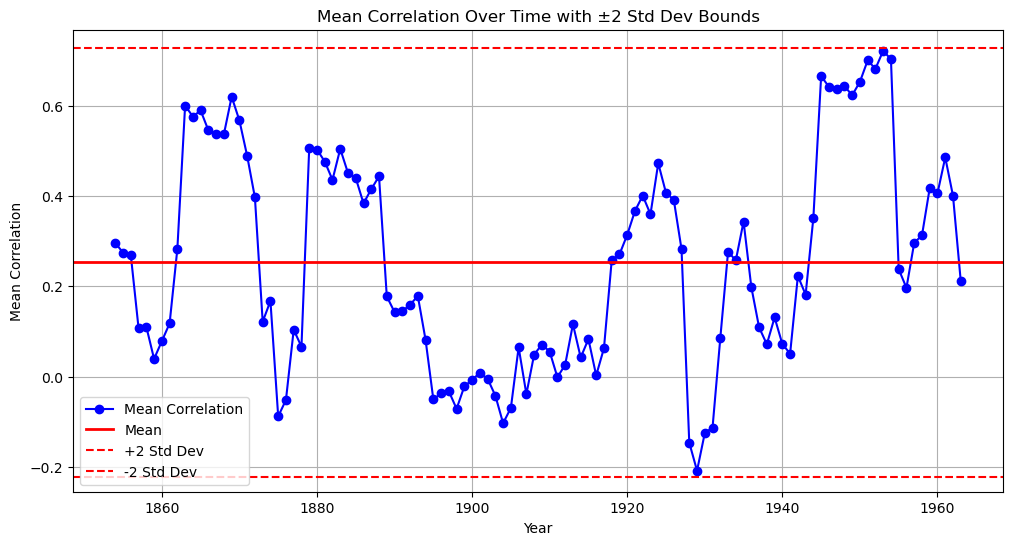

In [62]:
import matplotlib.pyplot as plt
import numpy as np

# Drop NaN values
df_corr = corr_df.dropna().copy()

# Compute mean and standard deviation
mean_corr = df_corr["Mean_Correlation"].mean()
std_corr = df_corr["Mean_Correlation"].std()

# Calculate +/- 2 standard deviations from the mean
upper_bound = mean_corr + 2 * std_corr
lower_bound = mean_corr - 2 * std_corr

# Plot the correlation over time
plt.figure(figsize=(12, 6))
plt.plot(
    df_corr.index,
    df_corr["Mean_Correlation"],
    marker="o",
    linestyle="-",
    color="b",
    label="Mean Correlation",
)

# Plot the mean as a horizontal red line
plt.axhline(y=mean_corr, color="red", linestyle="-", linewidth=2, label="Mean")

# Plot +/- 2 standard deviations as dashed red lines
plt.axhline(
    y=upper_bound, color="red", linestyle="--", linewidth=1.5, label="+2 Std Dev"
)
plt.axhline(
    y=lower_bound, color="red", linestyle="--", linewidth=1.5, label="-2 Std Dev"
)

plt.xlabel("Year")
plt.ylabel("Mean Correlation")
plt.title("Mean Correlation Over Time with ±2 Std Dev Bounds")
plt.legend()
plt.grid(True)

# Save the figure
plt.savefig("correlation_with_std_bounds.png")

# Show the plot
plt.show()

<Figure size 1200x600 with 0 Axes>

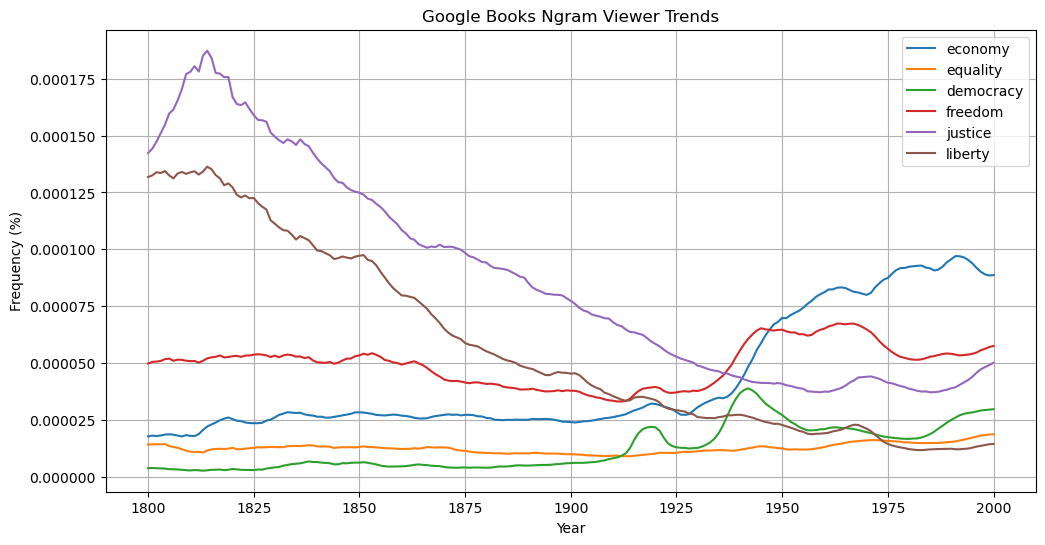

In [71]:
import requests
import pandas as pd
import matplotlib.pyplot as plt

import requests
import pandas as pd


def get_ngram_data(words, start_year=1800, end_year=2000):
    df = pd.DataFrame(index=range(start_year, end_year + 1))
    for word in words:
        url = f"https://books.google.com/ngrams/json?content={word}&year_start={start_year}&year_end={end_year}&corpus=26&smoothing=3"
        response = requests.get(url)
        data = response.json()
        if data:
            df[word] = pd.Series(
                data[0]["timeseries"], index=range(start_year, end_year + 1)
            )
    return df


# Example usage
words = ["economy", "equality", "democracy", "freedom", "justice", "liberty"]
start_year = 1850
end_year = 1965
df = get_ngram_data(words)
df.to_csv(f"ngram from {start_year}-{end_year}.csv")

# Plot
plt.figure(figsize=(12, 6))
df.plot(figsize=(12, 6))
plt.title("Google Books Ngram Viewer Trends")
plt.xlabel("Year")
plt.ylabel("Frequency (%)")
plt.grid(True)
plt.savefig("ngram_trends.png")
plt.show()

In [67]:
df.head()

,Fredericka Mandelbaum,robin hood,jesse james,outlaw,mafia,organized crime
1800,0.0,1.892719e-09,0.0,4.880376e-07,3.100845e-08,0.0
1801,0.0,1.514175e-09,0.0,5.295465e-07,3.260768e-08,0.0
1802,0.0,1.261813e-09,0.0,5.755062e-07,3.122492e-08,0.0
1803,0.0,1.081554e-09,0.0,5.859551e-07,2.816822e-08,0.0
1804,0.0,0.000000e+00,0.0,5.990601e-07,2.772853e-08,0.0
